In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Moedelling
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV,train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor



In [2]:
df=pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X=df.drop(columns=['math_score'],axis=1)

In [5]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
y=df['math_score']

In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer([
    ('OneHotEncoder',oh_transformer,cat_features),
    ('StandardScaler',numerical_transformer,num_features)
])

In [10]:
X=preprocessor.fit_transform(X)

In [11]:
X.shape

(1000, 19)

In [12]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((800, 19), (200, 19), (800,), (200,))

In [ ]:
def evaluate_model(train,predicate):
    mse=mean_squared_error(train,predicate)
   
    mae=mean_absolute_error(train,predicate)
    rmse=np.sqrt(mse)
    r2_square=r2_score(train,predicate)
    
    return mse,mae,rmse,r2_square

In [19]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()

}

model_list=[]
r2_list=[]


for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    #predicate 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

     # Evaluate Train and Test dataset
    model_train_mse , model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mse , model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Mean Squared Error: {:.4f}".format(model_train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Mean Squared Error: {:.4f}".format(model_test_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')





Linear Regression
Model performance for Training set
- Mean Squared Error: 28.3349
- Root Mean Squared Error: 4.2667
- Mean Absolute Error: 5.3231
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 29.0952
- Root Mean Squared Error: 4.2148
- Mean Absolute Error: 5.3940
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Mean Squared Error: 43.4784
- Root Mean Squared Error: 5.2063
- Mean Absolute Error: 6.5938
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Mean Squared Error: 42.5064
- Root Mean Squared Error: 5.1579
- Mean Absolute Error: 6.5197
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Mean Squared Error: 28.3378
- Root Mean Squared Error: 4.2650
- Mean Absolute Error: 5.3233
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Mean Squared Error: 29.0563
- Root Mean Squared Error: 4.2111
- Mean Absolute Error: 5.3904
- R2

In [21]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.851423
8,AdaBoost Regressor,0.845108
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.751293


LINEAR REGRESSION

In [26]:
model=LinearRegression(fit_intercept=True)
model=model.fit(X_train,y_train)
y_pred=model.predict(X_test)
score=r2_score(y_test,y_pred)
print("R2 score of Linear Regression model is: %.2f " %score)

R2 score of Linear Regression model is: 0.88 


Text(0, 0.5, 'Predicted Scores')

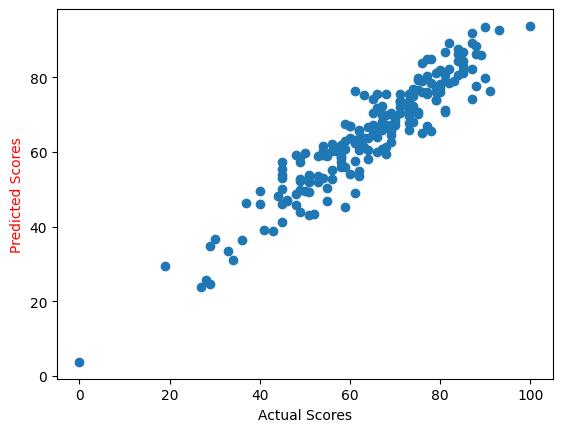

In [28]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores",color='red')

<Axes: xlabel='math_score'>

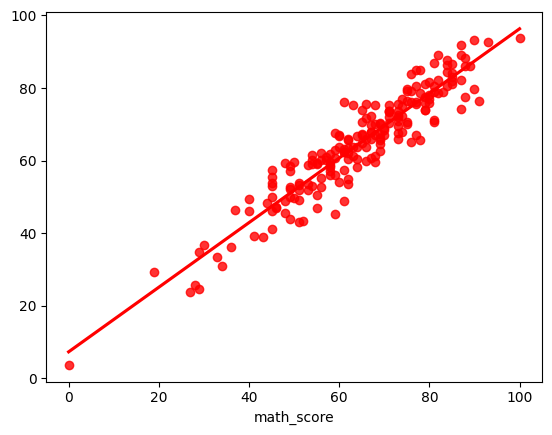

In [29]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [31]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
